## Position of a star

### Part 1
Likelihood, MLE estimator 


In [131]:
import numpy as np 
import matplotlib.pyplot as plt 
import random
from random import sample
import scipy.stats 
from astroML.datasets import fetch_dr7_quasar  

In some cases (for example N=5 and random seed(2)) the Likelihood is much less than the other distributions. But it is just a case, in N increases it doesn't happen 


They are single individual likelihoods: the probability of collecting the data I have collected given the parameters 

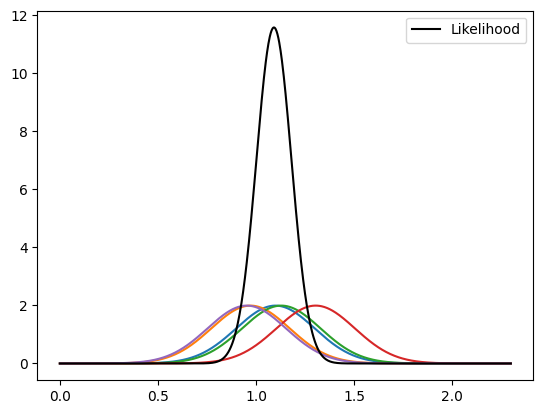

In [132]:
N=5      #number of measurements 

#the underlying process is Gaussian
mu=1
sigma=0.2

np.random.seed(42)
gauss = scipy.stats.norm(loc=mu,scale=sigma)
sample=gauss.rvs(N)                                 #N samples drawn from the Gaussian distribution

x_plot=np.linspace(0,2.3,1000)

L=1

for i in sample:
    distrib=scipy.stats.norm(i,sigma)               #different gaussian centered in the measurements
    plt.plot(x_plot,distrib.pdf(x_plot))
    L*=distrib.pdf(x_plot)


plt.plot(x_plot,L, label="Likelihood", color='black')
plt.legend()
plt.show()


In [133]:
max_like=max(L) #maximum likelihood
max_index=np.where(L==max_like) #index of maximum 
max_L=x_plot[max_index] #x of maximum 


print("%0.9f" % np.mean(sample), "is the MLE for mu")
print("%0.9f" % max_L[0], "is the max of likelihood (computed numerically)")

1.091800595 is the MLE for mu
1.091291291 is the max of likelihood (computed numerically)


Here I flipped the line of argument 

(1000, 5)
(1000,)


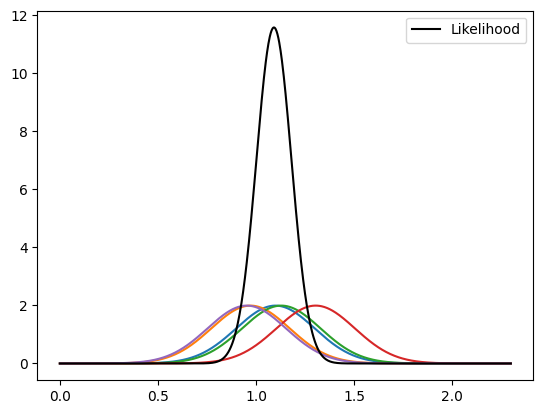

In [ ]:
N=5      #number of measurements 

mu=1
sigma=0.2

np.random.seed(42)
gauss = scipy.stats.norm(loc=mu,scale=sigma)
sample=gauss.rvs(N)                                 #N samples drawn from the Gaussian distribution

mu_plot=np.linspace(0,2.3,1000)                     #value of the likelihood for different mu 

Ls2 = np.array([scipy.stats.norm.pdf(sample,loc=s,scale=sigma) for s in mu_plot])  #likelihood for each mu for all samples

# a different gaussian evaluated with different mu for each sample
L2=np.prod(Ls2, axis=1)  #product of all likelihoods for each mu

plt.plot(mu_plot,Ls2[0:])
plt.plot(mu_plot,L2, label="Likelihood", color='black')
plt.legend()
plt.show()

In [ ]:
max_like2=max(L2) #maximum likelihood
max_index2=np.where(L2==max_like) #index of maximum 
max_L2=x_plot[max_index2] #x of maximum 


print("%0.9f" % max_L[0], "First method")
print("%0.9f" % max_L2[0], "Second method")

1.091291291 First method
1.091291291 Second method


The two methods are the same because $\mu$ e x sono simmetriche per una gaussiana

### Part 2
Uncertainties of MLE, second order differentiation

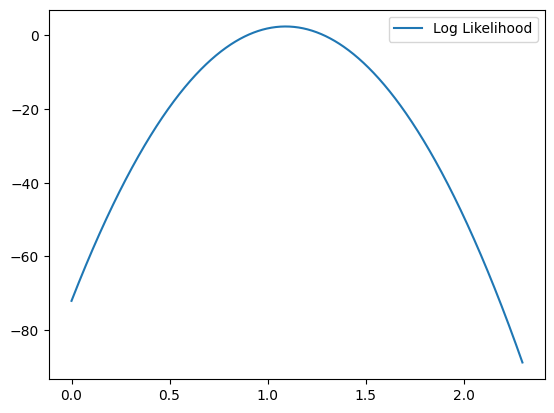

In [ ]:

l=np.log(L) #log of likelihood 
plt.plot(x_plot,l, label="Log Likelihood")
plt.legend()
plt.show()


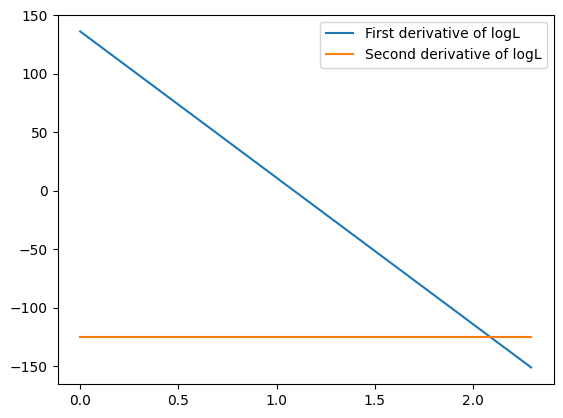

0.08944271909997202064 is MLE for sigma
0.08944271909999158832 is the theoretical error for mu


In [ ]:
d1=np.diff(l)/np.diff(x_plot) #first derivative: ratio between small increments on x and y 

plt.plot(x_plot[0:len(d1)],d1, label='First derivative of logL') #the length of d1 is one less than the length of the x 

d2=np.diff(d1)/np.diff(x_plot[0:len(d1)]) #second derivative

plt.plot(x_plot[0:len(d2)],d2, label='Second derivative of logL')
plt.legend() #at the extrema is quite noisy 
plt.show()

sigma_mu=(-d2[max_index])**(-0.5) #result of the Fischer matrix

err_mu_th=sigma/np.sqrt(N)

print("%0.20f" % sigma_mu[0], "is MLE for sigma")
print("%0.20f" % err_mu_th, "is the theoretical error for mu") 
#the difference appears after several decimal digits

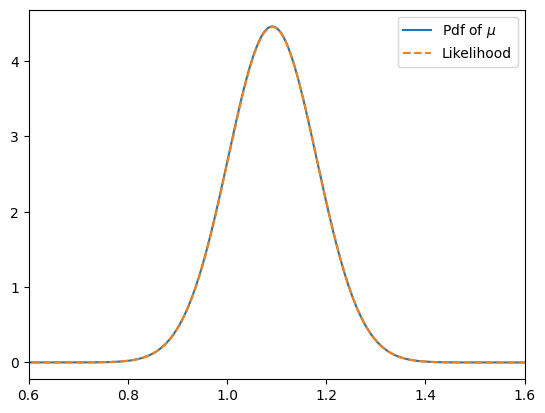

In [176]:
plt.plot(x_plot, scipy.stats.norm.pdf(x_plot, max_L[0], sigma_mu), label=r"Pdf of $\mu$")
plt.plot(x_plot,L/2.6, label="Likelihood", ls='dashed')
plt.xlim(0.6,1.6)
plt.legend()
plt.show()

The product of gaussians (the Likelihood) is still a gaussian with same $\mu$ but $\sigma_{product}=\sigma/\sqrt{N}$ and a different normalization. For the normalization we need to expand the quadratic form
 

